## Импорт основных библиотек

In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [26]:
import numpy as np
import pandas as pd
from helper import *
from plots import *
import random

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

##  1. Изучение структуры данных

In [4]:
# Загружаем датасет в память
df = pd.read_csv("diamonds.csv", index_col=0)
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
# Смотрим на детали
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


Пропущенных значений не имеется

In [6]:
# Смотрим на статистики по числовым переменным (категориальные сюда не входят)
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 2. Проверка на корректность и качество данных

### 2.1 Проверка на дубликаты

In [50]:
# Подсчет числа дублированных строк
df.duplicated().sum() 

np.int64(146)

### 2.2 Пропущенные значения

In [8]:
# выводим число пропущенных значений по каждому столбцу
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

### 2.3 Камни с нулевой шириной / длиной / высотой (x,y,z)

In [47]:
(df["x"] == 0).sum()

np.int64(8)

In [48]:
(df["y"] == 0).sum()

np.int64(7)

In [49]:
(df["z"] == 0).sum()

np.int64(20)

## 3. Детальное изучение признаков (и таргета)

### 3.1 Числовые переменные

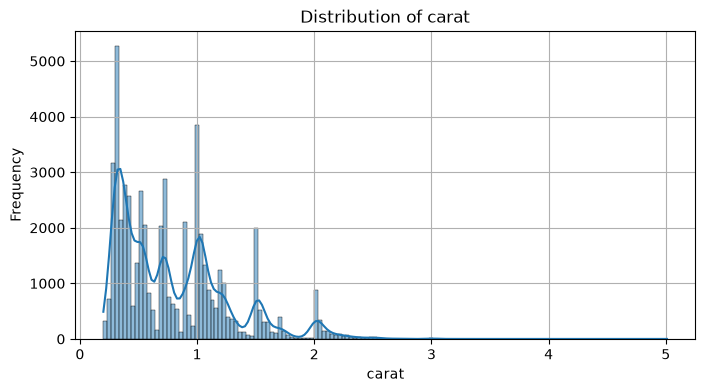

In [9]:
# Строим гистограмму распределения carat
plot_hist_numeric(df, 'carat')

Видно, что есть пики в районе 0.3, 1, 1.5 и 2 карат

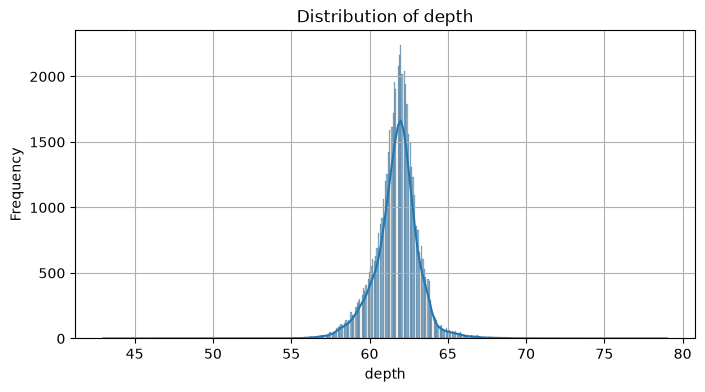

In [10]:
# Строим гистограмму распределения depth
plot_hist_numeric(df, 'depth')

Видно, что значения сконцентрировались в диапазоне 55-67 процентов. Остальные можно считать выбросами

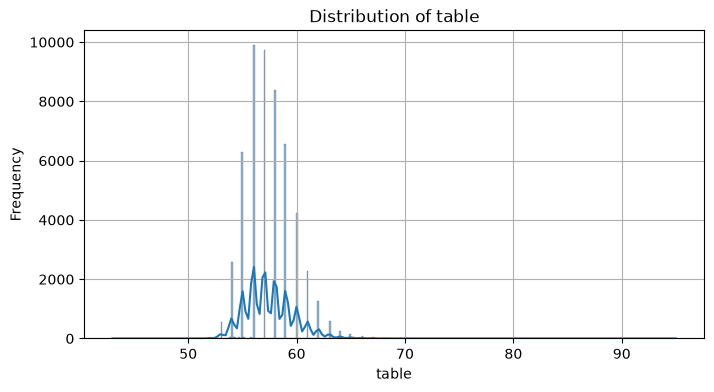

In [11]:
# Строим гистограмму распределения table
plot_hist_numeric(df, 'table')

Видно, что в целом распределение выглядит как нормальное, но значения округлялись. Значения лежат в диапазоне 50-65 процентов

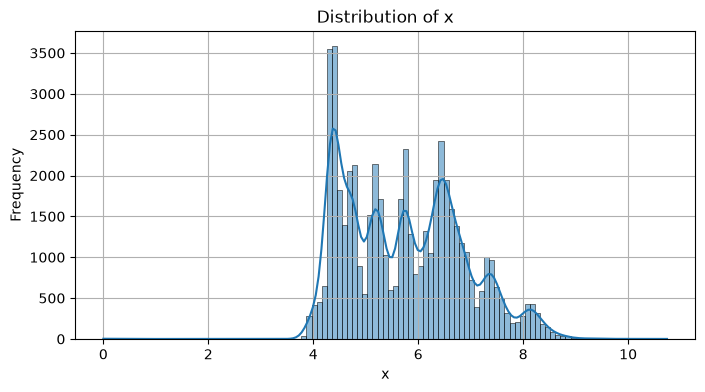

In [12]:
# Строим гистограмму распределения x
plot_hist_numeric(df, 'x')

Длина может варьироваться, распределение ненормальное. Значения в диапазоне 4-9 мм

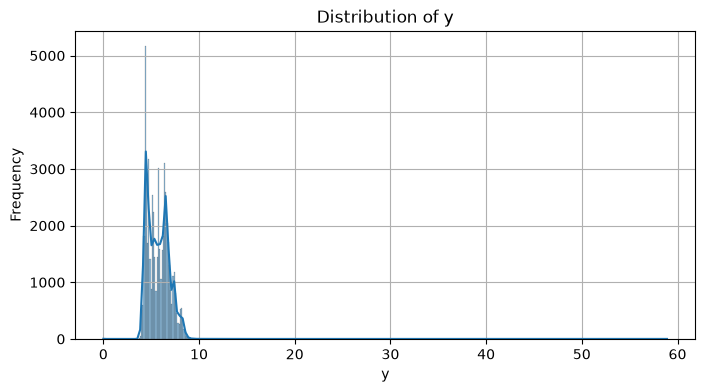

In [13]:
# Строим гистограмму распределения y (ширина)
plot_hist_numeric(df, 'y')

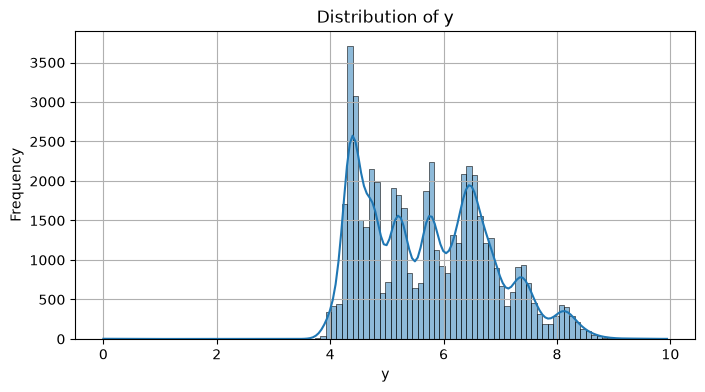

In [14]:
# Выведем значения между 0 и 10
df_filtered = df[df['y'].between(0, 10)]
plot_hist_numeric(df_filtered, 'y')

Имеются большие выбросы, распределение также ненормальное, похоже на 'x' (длина). Значения в диапазоне 4-9 мм

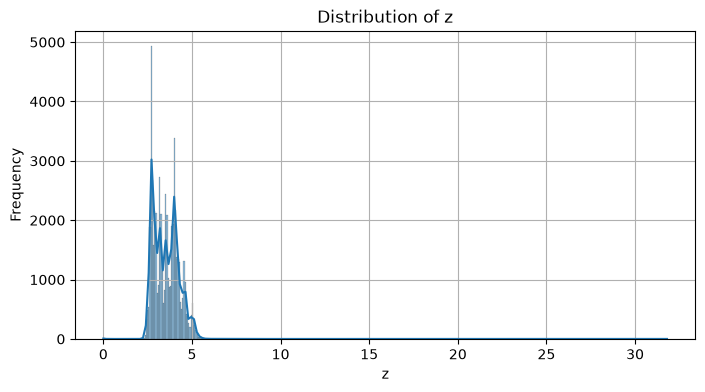

In [15]:
# Строим гистограмму распределения z (высота)
plot_hist_numeric(df, 'z')

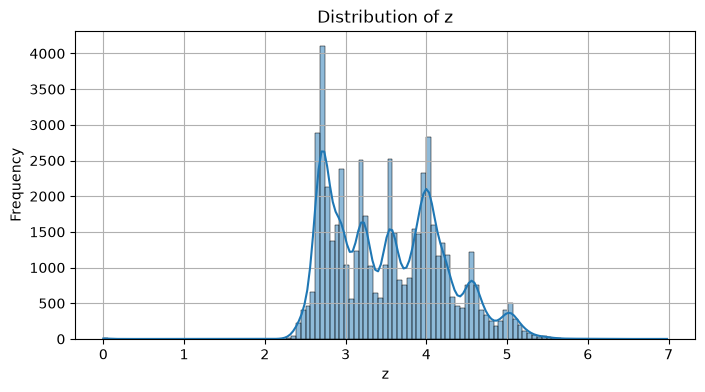

In [16]:
# Выведем значения между 0 и 10
df_filtered = df[df['z'].between(0, 7)]
plot_hist_numeric(df_filtered, 'z')

Распределение похоже на предыдущие 'x' и 'y' (длина и ширина соответственно), однако значения немного сдвинуты на ~2мм. Значения в диапазоне 2-6 мм

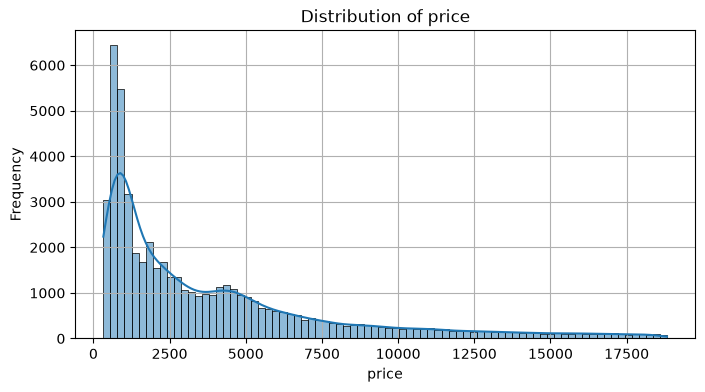

In [17]:
# Строим гистограмму распределения price (наш таргет)
plot_hist_numeric(df, 'price')

Имеется сильный перекос, большинство значений лежат от 0 до 8000$

### 3.2 Категориальные переменные

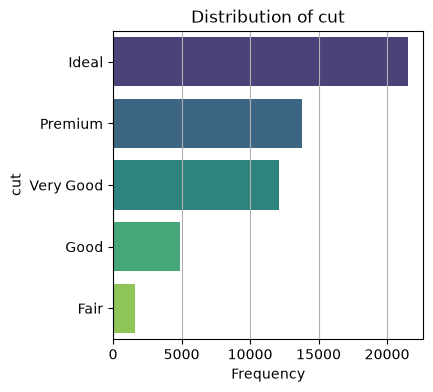

In [18]:
# Строим гистограмму распределения cut
plot_hist_categorical(df, 'cut')

Большинство строк с идеальным качеством огранки, мало значений с нормальным (Fair)

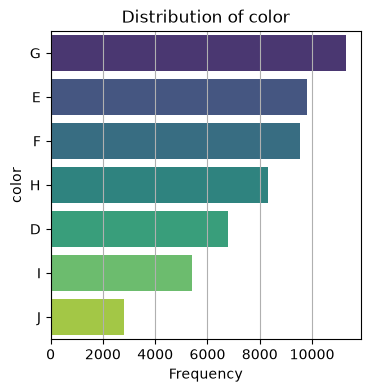

In [19]:
# Строим гистограмму распределения color
plot_hist_categorical(df, 'color')

| Категория | Описание |
|------------|----------|
| `D` | Абсолютно бесцветный. Наивысшая категория цвета, самые редкие и дорогие бриллианты. |
| `E` | Практически бесцветный. Незначительные оттенки заметны только при профессиональной оценке. |
| `F` | Практически бесцветный. Очень высокое качество цвета. |
| `G` | Почти бесцветный. Легкий оттенок практически незаметен невооруженным глазом. |
| `H` | Почти бесцветный. Незначительный оттенок может быть заметен при сравнении с более качественными камнями. |
| `I` | Слабый желтоватый или коричневатый оттенок, заметный при внимательном рассмотрении. |
| `J` | Наиболее выраженный оттенок среди представленных в датасете. Такие бриллианты обычно имеют более низкую стоимость по сравнению с категориями `D–I`. |

В целом датасет содержит преимущественно бриллианты среднего качества по цвету

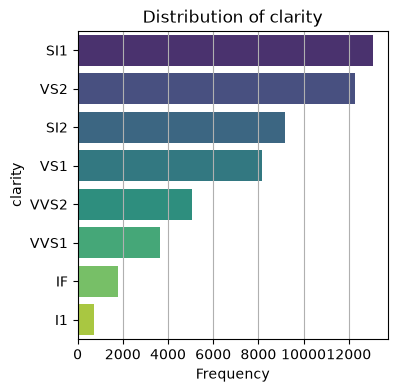

In [20]:
# Строим гистограмму распределения clarity
plot_hist_categorical(df, 'clarity')

| Категория | Описание |
|------------|----------|
| `IF` | **Internally Flawless** — внутренние дефекты отсутствуют, имеются лишь незначительные поверхностные несовершенства. Наивысшая категория чистоты в датасете. |
| `VVS1` | **Very Very Slightly Included 1** — крайне незначительные включения, практически незаметные даже при 10-кратном увеличении. |
| `VVS2` | **Very Very Slightly Included 2** — очень незначительные включения, немного более заметные, чем у `VVS1`. |
| `VS1` | **Very Slightly Included 1** — очень мелкие включения, трудно различимые при 10-кратном увеличении. |
| `VS2` | **Very Slightly Included 2** — небольшие включения, заметные специалисту при увеличении. |
| `SI1` | **Slightly Included 1** — небольшие включения, которые могут быть заметны при увеличении и иногда невооруженным глазом. |
| `SI2` | **Slightly Included 2** — включения более выражены, чем у `SI1`, и чаще заметны без увеличения. |
| `I1` | **Included 1** — заметные внутренние включения, влияющие на внешний вид и стоимость бриллианта. |

Распределение является неравномерным: большинство бриллиантов относятся к категориям средней чистоты (SI и VS), тогда как камни с очень высокой или низкой чистотой представлены существенно меньшим числом строк

## 4. Изучение взаимосвязей между признаками

### 4.1 Общая матрица корреляций

Наша цель состоит в том, чтобы понять, какие столбцы коррелируют друг с другом наиболее сильно и далее изучить подробнее эти корреляции. также понять, какие из столбцов сильнее всего коррелируют с таргетом

interval columns not set, guessing: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


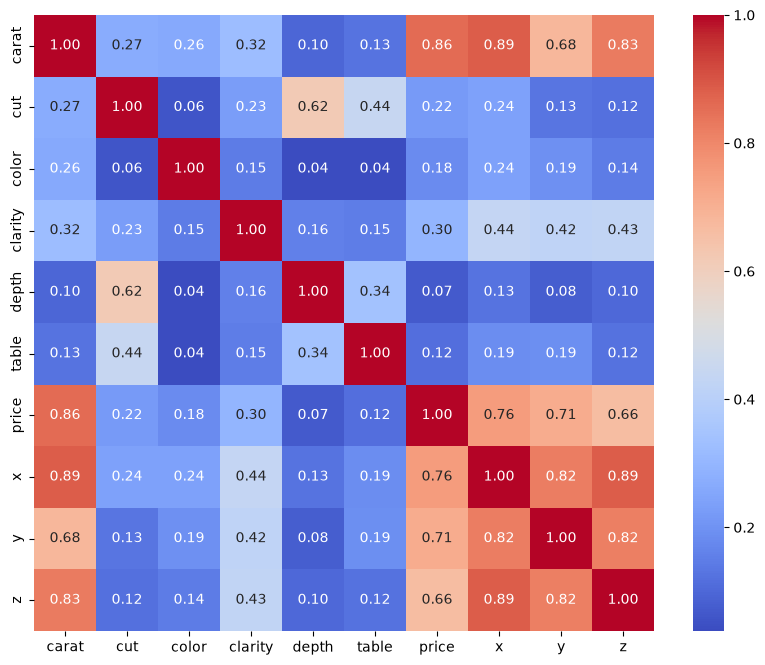

In [21]:
# поскольку в нашем датасете присутствуют категориальные признаки, используем корреляцию phik, которая способна с ними работать
plot_phik(df)

Обращаем внимание на ячейки с более высокими значениями корреляции. Видим, что наиболее сильные связки это: 
- price vs carat
- price vs clarity
- clarity vs x / y / z
- depth vs cut
- price vs x / y / z (аналогично с весом)
- carat vs x / y / z (вес зависит от размеро, логично)
- x vs y vs z (размеры друг от друга зависят)

### 4.2 Подробное изучение корреляций между выбранными парами

#### 4.2.1 price vs carat

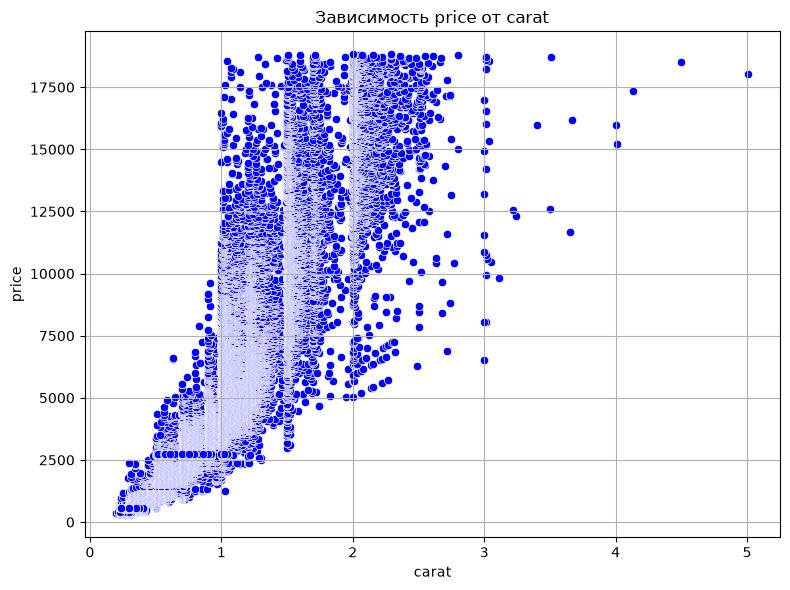

In [23]:
plot_numeric_relationship(
    df, 
    "carat", 
    "price",
)

- Наблюдается положительная зависимость: с ростом веса (carat) цена в среднем растёт.

#### 4.2.2 price vs clarity

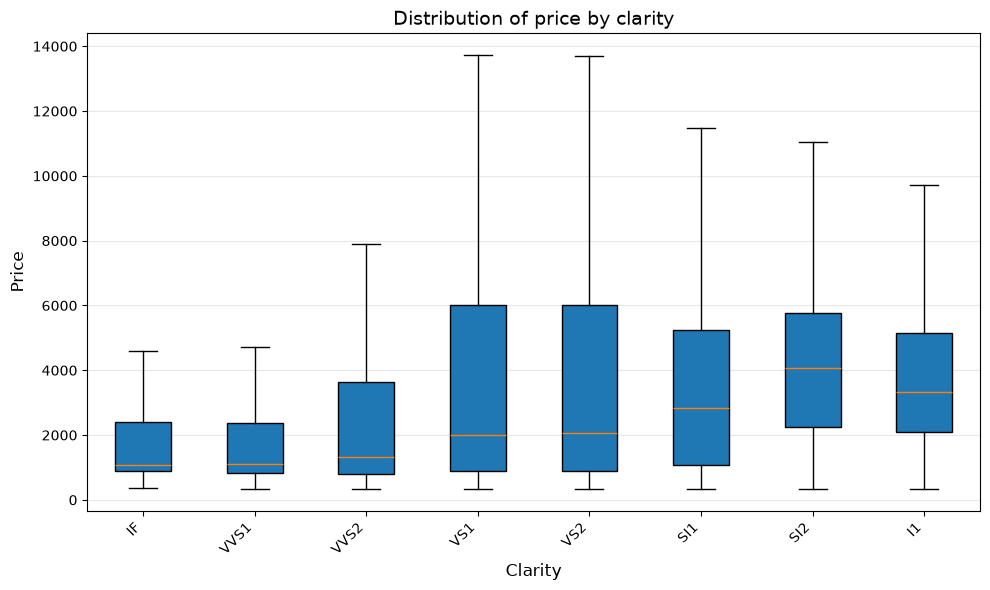

In [33]:
clarities = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
plot_box_by_category(df, cat_feature="clarity", num_feature="price", showfliers=False, categories=clarities)

- Медианные цены заметно различаются по категориям чистоты. Наиболее низкие медианы у IF и VVS1 (примерно 1000–1500), более высокие - у SI1, SI2 (около 2000-4000).
- Самый большой разброс цен (длинные усы и высокие выбросы до ~14 000) наблюдается у VS1 и VS2. У IF и VVS1 разброс заметно меньше.
- На удивление, после сортировки по чистоте (от лучшей к худшей) четкой тенденции "чем выше чистота, тем выше цена" не наблюдается

#### 4.2.3 clarity vs x / y / z

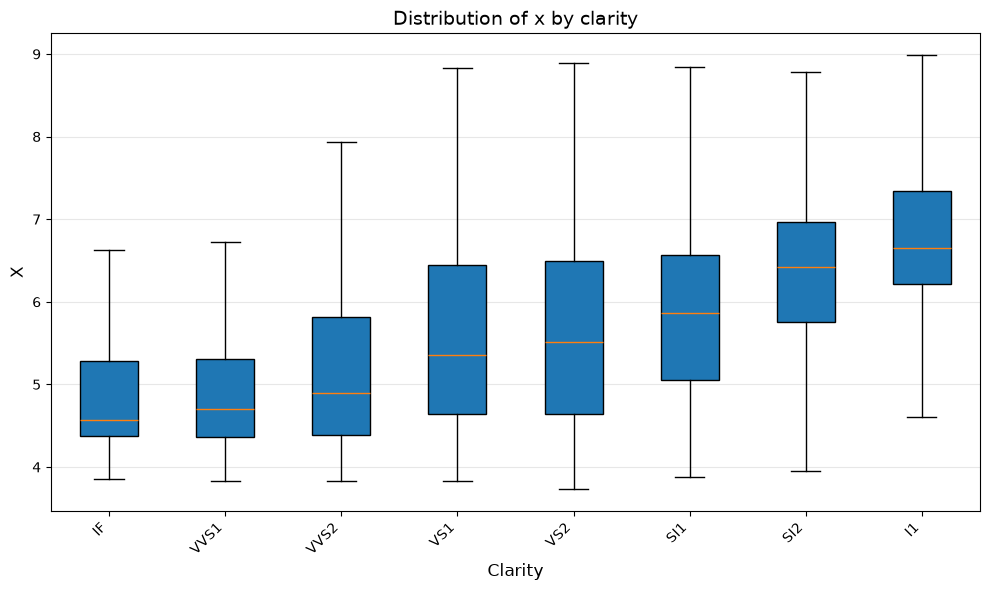

In [34]:
plot_box_by_category(df, cat_feature="clarity", num_feature="x", showfliers=False, categories=clarities)

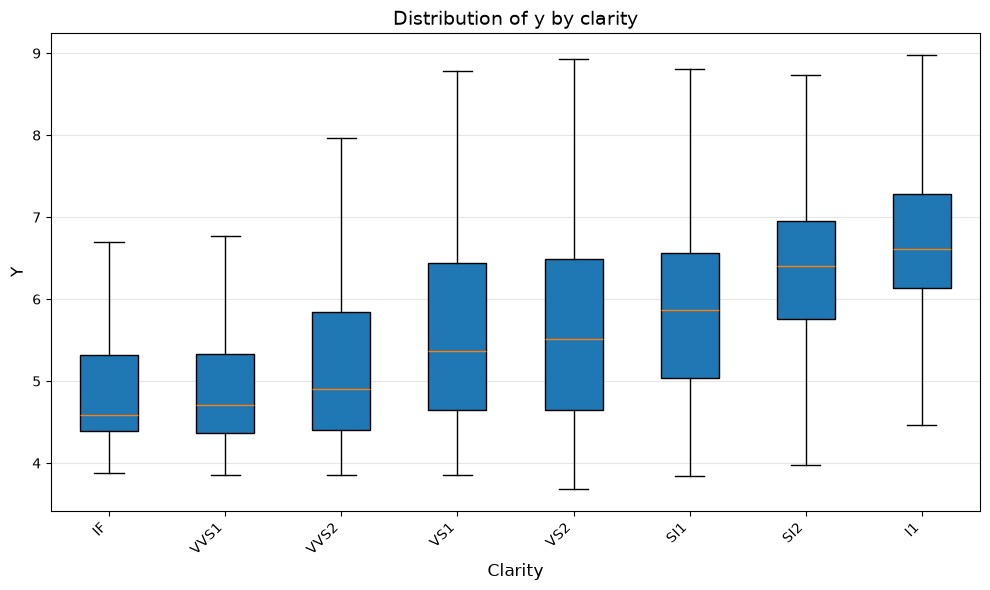

In [35]:
plot_box_by_category(df, cat_feature="clarity", num_feature="y", showfliers=False, categories=clarities)

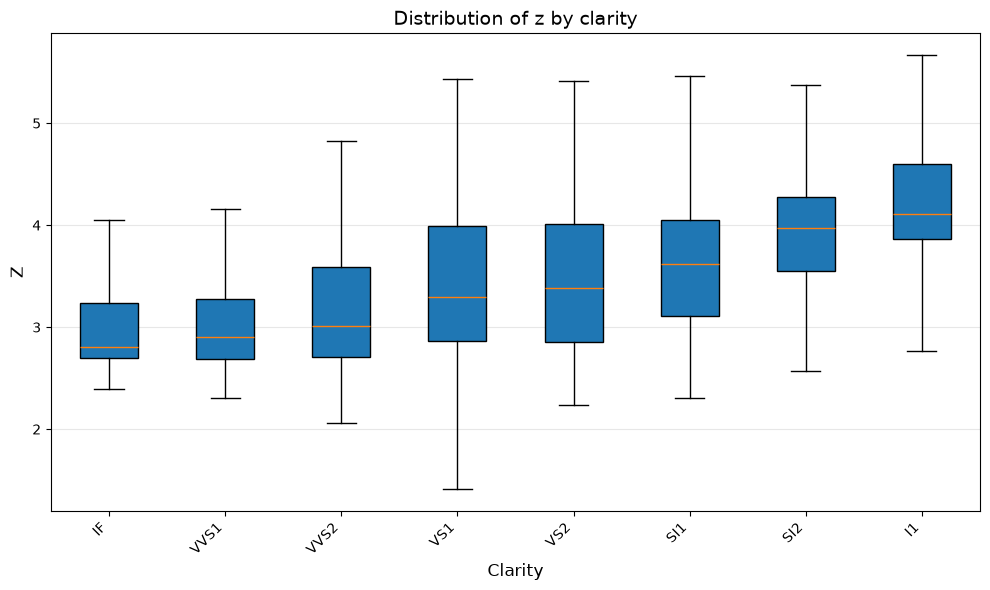

In [36]:
plot_box_by_category(df, cat_feature="clarity", num_feature="z", showfliers=False, categories=clarities)

- Алмазы с более низкой чистотой (I1, SI1, SI2) в среднем крупнее по всем трём измерениям (x, y, z).
- Алмазы с высокой чистотой (IF, VVS1, VVS2) в среднем меньше.

#### 4.2.4 depth vs cut

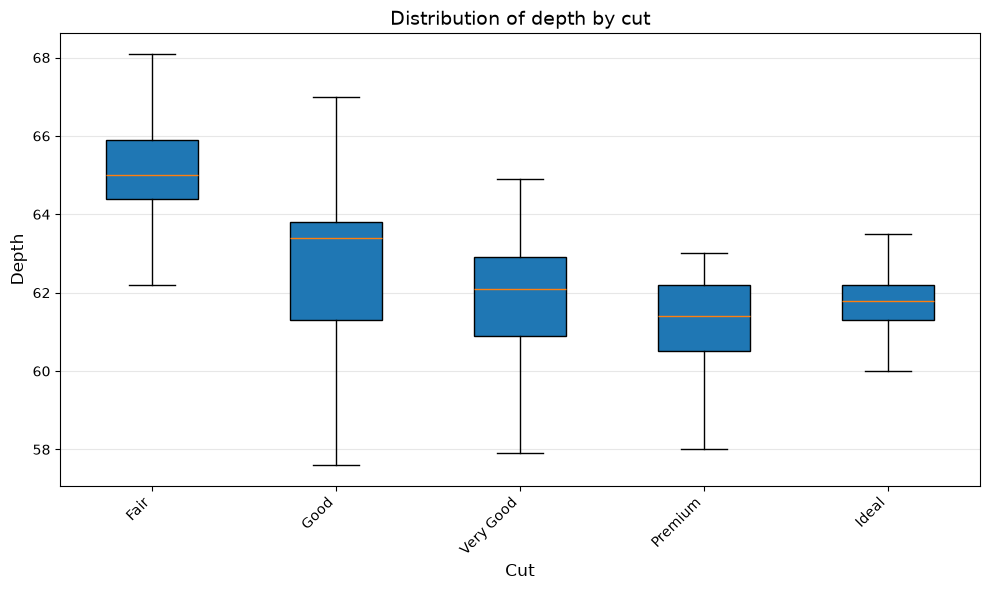

In [38]:
cuts = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
plot_box_by_category(df, cat_feature="cut", num_feature="depth", showfliers=False, categories=cuts)

- Наблюдается чёткая обратная зависимость: чем выше качество огранки (cut), тем ниже медианное значение depth.

#### 4.2.5 price vs x / y / z

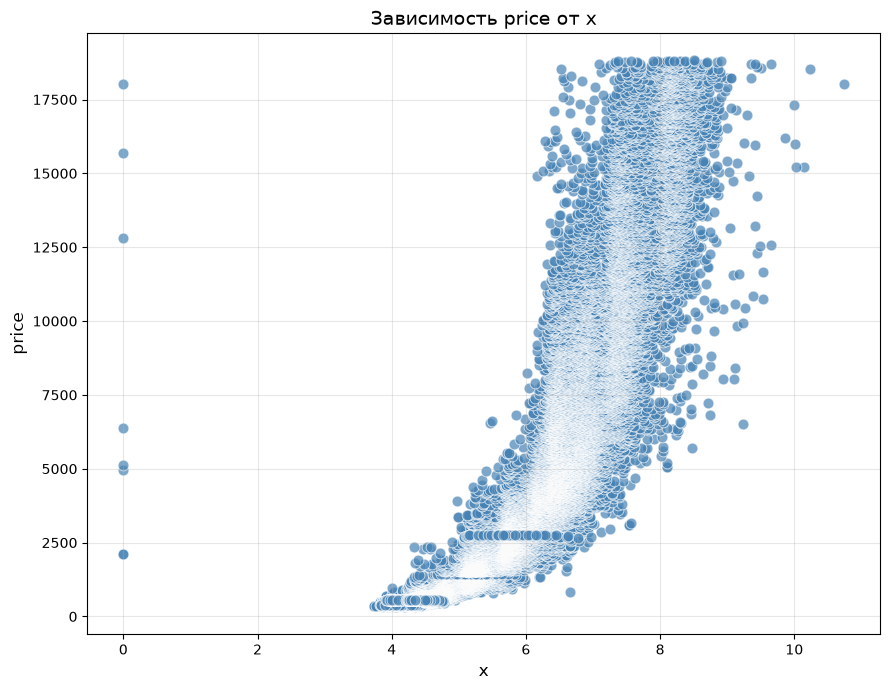

In [45]:
plot_numeric_relationship(df, "x", "price")

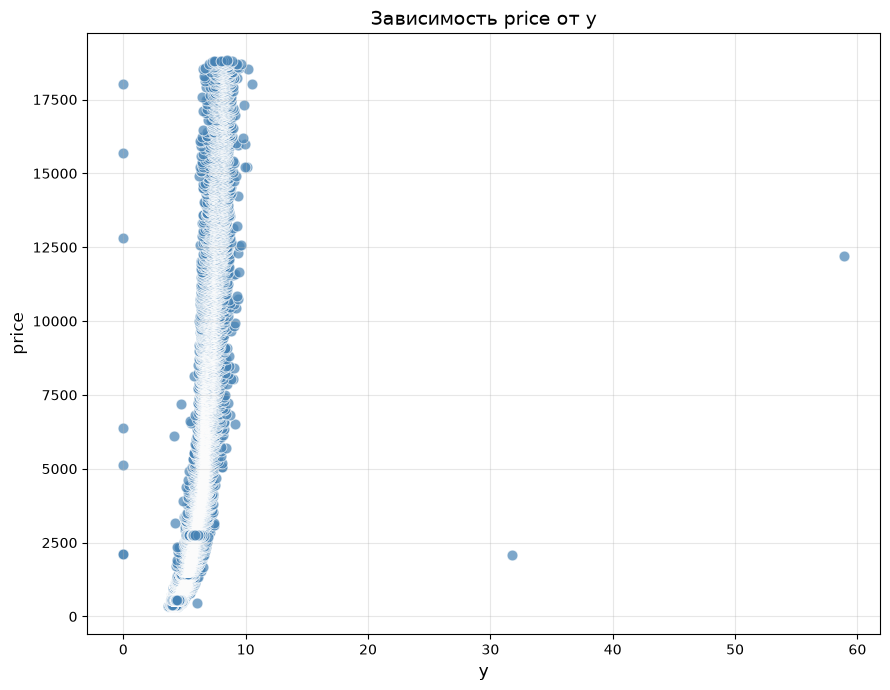

In [44]:
plot_numeric_relationship(df, "y", "price")

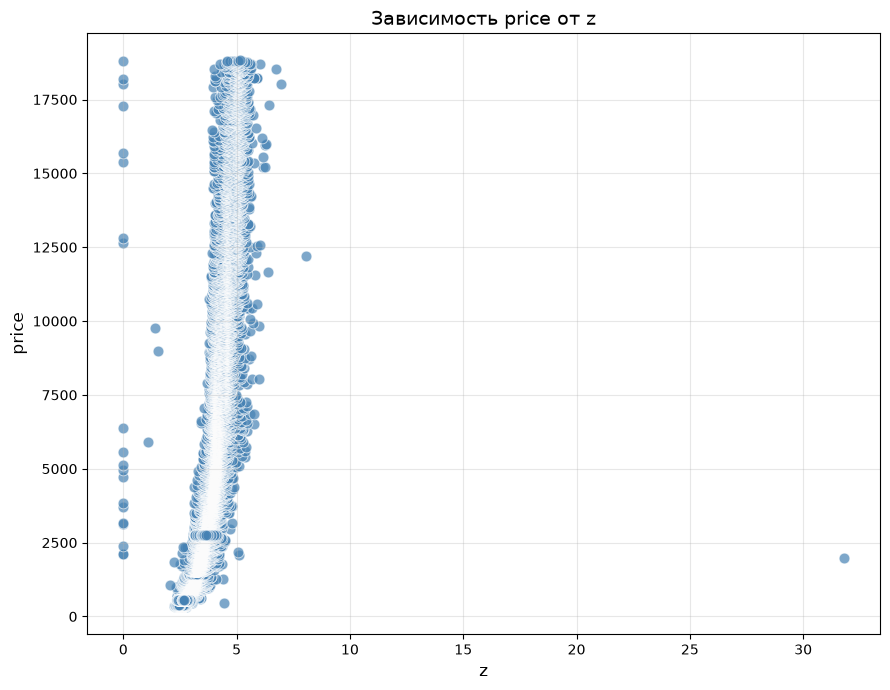

In [42]:
plot_numeric_relationship(df, "z", "price")

- Во всех трёх случаях видна положительная зависимость: чем больше размер камня (x, y или z), тем выше цена.

#### 4.2.6 carat vs x / y / z

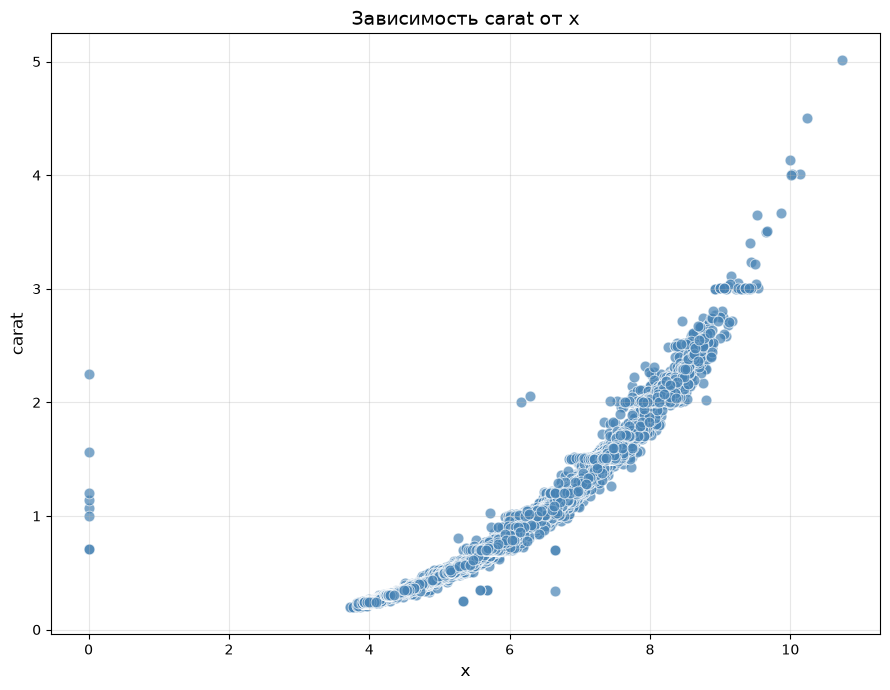

In [46]:
plot_numeric_relationship(df, "x", "carat")

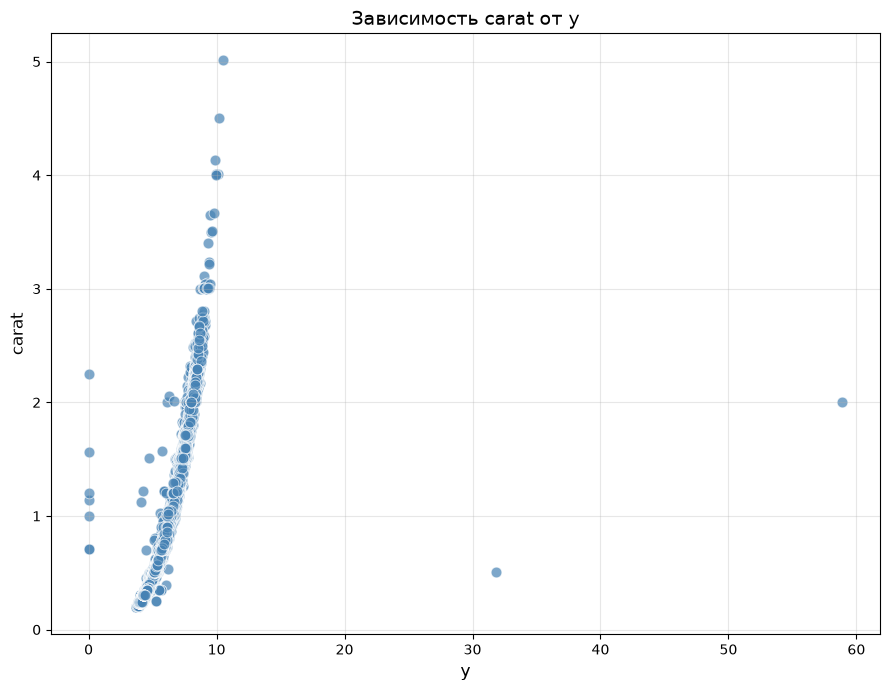

In [51]:
plot_numeric_relationship(df, "y", "carat")

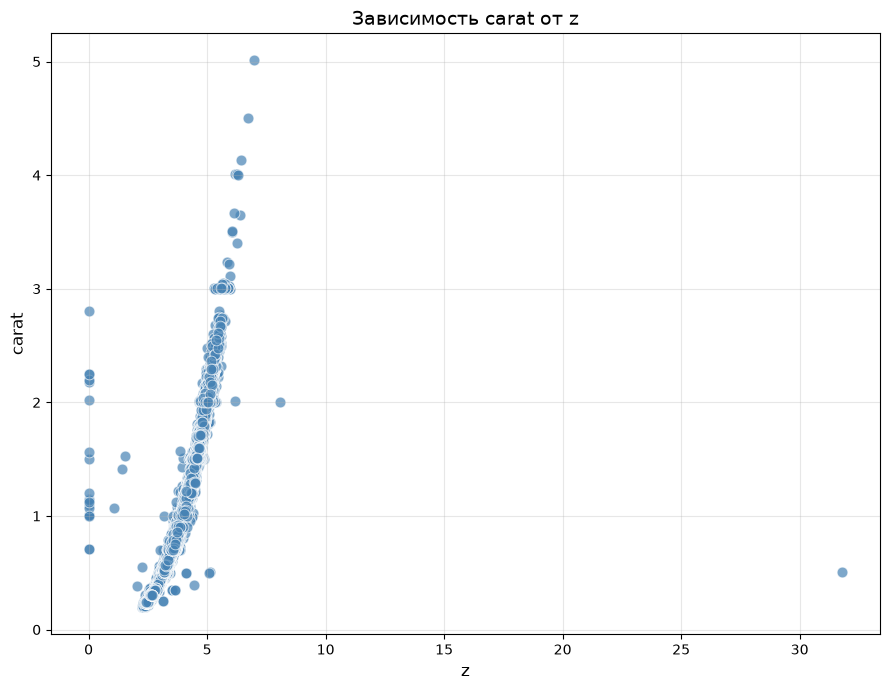

In [56]:
plot_numeric_relationship(df, "z", "carat")

- Также наблюдается логичная положительная зависимость: чем больше размер камня, тем больше вес

#### 4.2.7 x vs y vs z

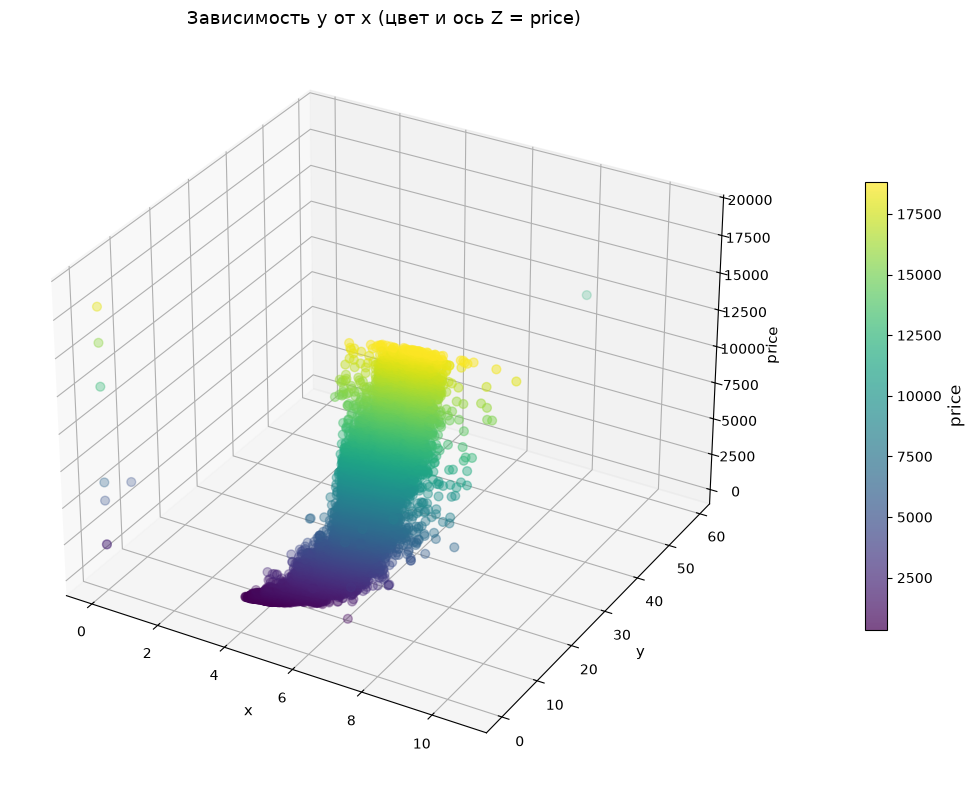

In [57]:
plot_numeric_relationship(df, "x", "y", target_col="price")

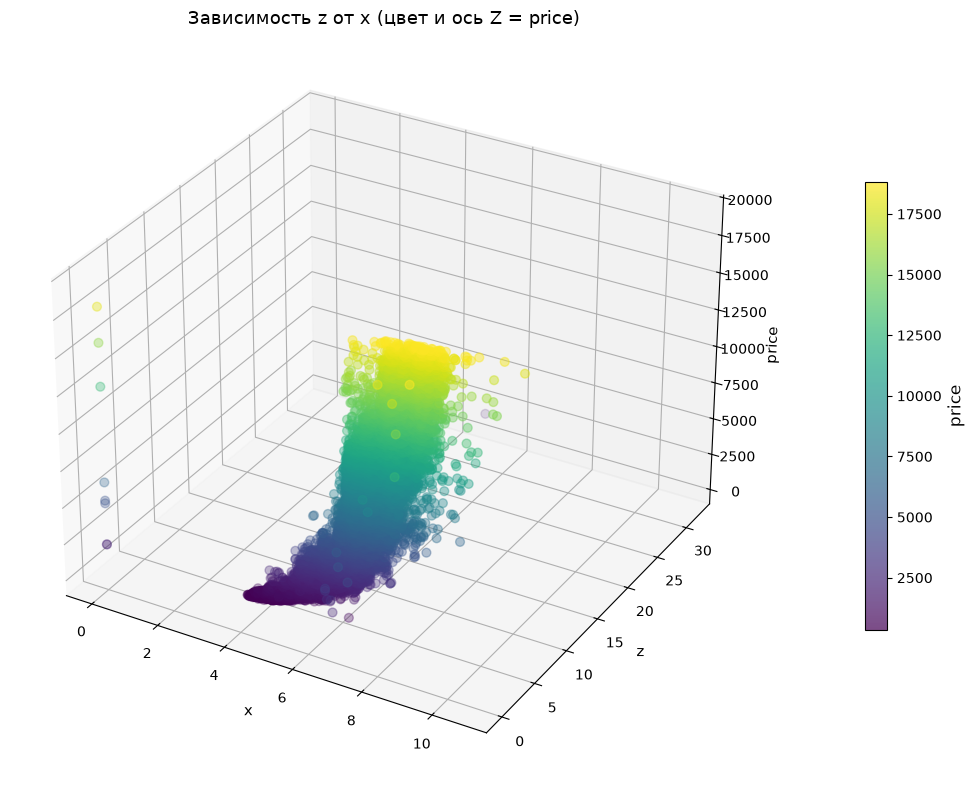

In [58]:
plot_numeric_relationship(df, "x", "z", target_col="price")

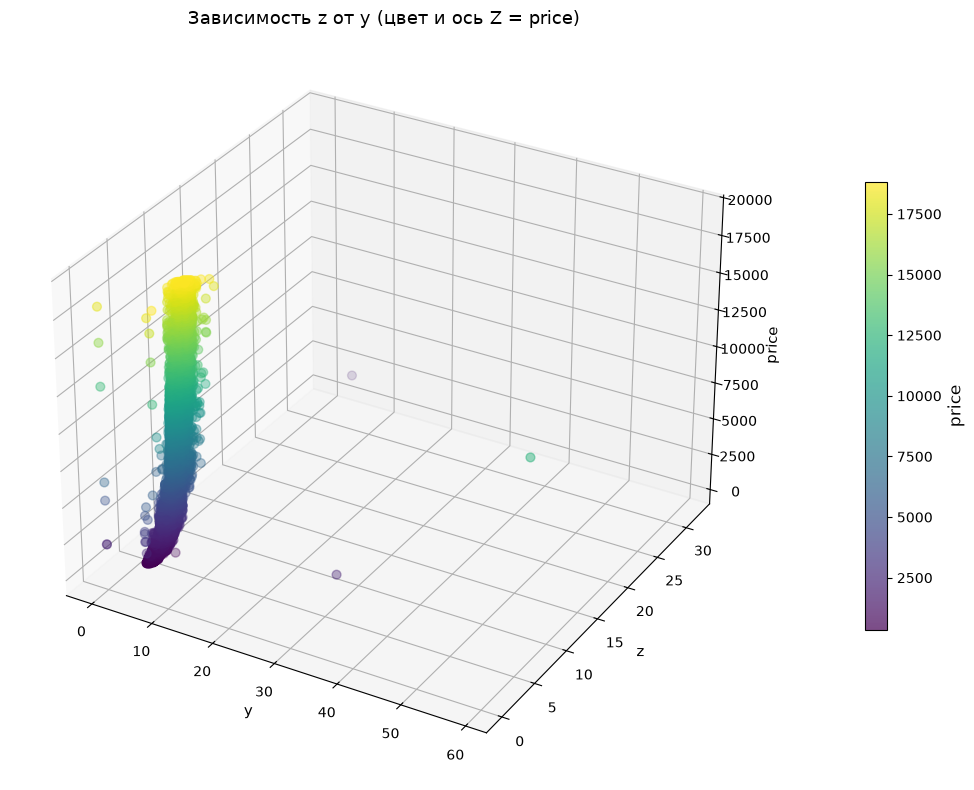

In [59]:
plot_numeric_relationship(df, "y", "z", target_col="price")

- Во всех трёх проекциях видна сильная положительная связь размеров с ценой: чем больше x, y или z, тем выше price